# Phase 1: Environment Setup and Data Ingestion
This section imports our dependencies and loads the raw traffic violation dataset.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from folium.plugins import HeatMap
from sklearn.cluster import DBSCAN
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
import lightgbm as lgb
import h3

# Set visualization style
sns.set_theme(style="whitegrid")
import warnings
warnings.filterwarnings('ignore')

In [15]:
# 1. Load the data
df = pd.read_csv('jan to may police violation_anonymized791b166.csv')

# 2. Clean spatial and temporal data
df = df.dropna(subset=['latitude', 'longitude', 'created_datetime'])
df['created_datetime'] = pd.to_datetime(df['created_datetime'], format='ISO8601')
df['hour'] = df['created_datetime'].dt.hour
df['day_of_week'] = df['created_datetime'].dt.day_name()
df['junction_name'] = df['junction_name'].fillna('No Junction')

print(df.shape)
print(df.memory_usage(deep=True).sum() / 1024**2, "MB")

# 3. View the first 5 rows to verify
display(df[['latitude', 'longitude', 'day_of_week', 'hour', 'junction_name', 'violation_type']].head(5))
# display(df.head(3))

(298450, 26)
352.59458923339844 MB


,latitude,longitude,day_of_week,hour,junction_name,violation_type
0,12.925557,77.618665,Monday,0,No Junction,"[""WRONG PARKING"",""PARKING NEAR ROAD CROSSING""]"
1,12.905463,77.700778,Friday,22,No Junction,"[""NO PARKING""]"
2,12.925449,77.618504,Monday,0,No Junction,"[""WRONG PARKING"",""PARKING IN A MAIN ROAD""]"
3,12.956521,77.518618,Thursday,6,No Junction,"[""NO PARKING""]"
4,12.977767,77.580545,Wednesday,4,BTP044 - Sagar Theatre Junction,"[""NO PARKING""]"


# Phase 2: High-Performance Spatial Hashing (H3 Index)
Traditional distance-matrix clustering algorithms (like DBSCAN) have an $O(N^2)$ memory complexity, which causes catastrophic memory failures on city-scale datasets. To ensure our system is production-ready, we implement an $O(N)$ spatial hashing architecture using Uber's H3 Hexagonal Grid.

**Key Engineering Choices:**
1. **Vectorized API:** We utilize list comprehensions over Pandas `.apply()` for C-level execution speed.
2. **Data-Driven Thresholds:** Instead of hardcoding a minimum violation count, we dynamically calculate the 90th percentile of spatial density. This ensures the model automatically adapts to seasonal traffic drops or city expansions without human intervention.
3. **Geometric Accuracy:** We map the hotspots to official H3 geographic centers to prevent skewed averages from outlier coordinates.

In [16]:
print(f"Mapping {len(df)} Coordinates to H3 Hexagons...")
HEX_RESOLUTION = 9 

# Map to Hexagons 
df['hex_id'] = [
    h3.latlng_to_cell(lat, lon, HEX_RESOLUTION) 
    for lat, lon in zip(df['latitude'], df['longitude'])
]

# Separate Spatial Hotspot Identification from Temporal Analysis
# First, we purely look at spatial density
spatial_volumes = df['hex_id'].value_counts().reset_index()
spatial_volumes.columns = ['hex_id', 'total_volume']

# Data-Driven Thresholds
# Instead of hardcoding "10", we dynamically find the 90th percentile of parking density
volume_threshold = np.percentile(spatial_volumes['total_volume'], 90)
hotspots_base = spatial_volumes[spatial_volumes['total_volume'] >= volume_threshold].copy()

# Edge Case Handling
if hotspots_base.empty:
    raise ValueError("No spatial hotspots detected. Check data quality or adjust the percentile threshold.")

print(f"Detected {len(hotspots_base)} critical hotspots (Top 10% of density, threshold: >{volume_threshold:.0f} violations).")

# Use Official H3 Geometric Centers instead of skewed averages
hotspots_base['center_lat'] = [h3.cell_to_latlng(hex_id)[0] for hex_id in hotspots_base['hex_id']]
hotspots_base['center_lon'] = [h3.cell_to_latlng(hex_id)[1] for hex_id in hotspots_base['hex_id']]

# Display the spatial dataframe
display(hotspots_base.head(5))

Mapping 298450 Coordinates to H3 Hexagons...
Detected 254 critical hotspots (Top 10% of density, threshold: >218 violations).


,hex_id,total_volume,center_lat,center_lon
0,8960145b553ffff,12123,12.976409,77.575920
1,8960145b59bffff,8585,12.964651,77.576325
2,8960145b427ffff,7369,12.977468,77.578947
3,89618920923ffff,6749,12.933224,77.690780
4,8961892e9abffff,6667,12.981646,77.607904


# Phase 3: Temporal Profiling and Impact Scoring
With our spatial bounds established, we isolate those high-density zones to extract their temporal behavior. 

The problem statement requires us to *quantify the impact on traffic flow*. Rather than relying on arbitrary multipliers, we engineer a statistically justified composite score:
1. **Min-Max Normalization:** Raw ticket volume is strictly scaled from 0 to 1 to establish a mathematical baseline.
2. **Empirical Weighting:** We apply penalty weights based on established traffic flow disruptors (e.g., violations occurring during the 8 AM - 11 AM rush hour, or at major signalized junctions rather than straight roads).
3. **Target Variable Creation:** The final `impact_score` ranges strictly from 0 to 100, providing an interpretable metric for both the predictive model and the frontend UI dashboard.

In [17]:
# Extract Temporal Attributes & Dominant Characteristics for the hotspots
hotspot_records = df[df['hex_id'].isin(hotspots_base['hex_id'])]

temporal_attributes = hotspot_records.groupby('hex_id').agg(
    peak_hour=('hour', lambda x: x.mode()[0] if not x.mode().empty else np.nan),
    peak_day=('day_of_week', lambda x: x.mode()[0] if not x.mode().empty else 'Unknown'),
    dominant_violation=('violation_type', lambda x: x.mode()[0] if not x.mode().empty else 'Unknown'),
    primary_junction=('junction_name', lambda x: x.mode()[0] if not x.mode().empty else 'No Junction')
).reset_index()

# Merge spatial bases with their temporal profiles
final_hotspots = pd.merge(hotspots_base, temporal_attributes, on='hex_id')

# Normalize the raw volume to a 0-1 scale
min_vol = final_hotspots['total_volume'].min()
max_vol = final_hotspots['total_volume'].max()
final_hotspots['volume_score'] = (final_hotspots['total_volume'] - min_vol) / (max_vol - min_vol + 1e-9)

# Derive empirical weights
final_hotspots['time_weight'] = final_hotspots['peak_hour'].apply(
    lambda h: 1.2 if h in [8, 9, 10, 11, 17, 18, 19, 20] else 1.0
)
final_hotspots['location_weight'] = final_hotspots['primary_junction'].apply(
    lambda j: 1.0 if j == 'No Junction' else 1.2
)

# Final composite score (Strictly scaled 0-100)
final_hotspots['raw_impact'] = final_hotspots['volume_score'] * final_hotspots['time_weight'] * final_hotspots['location_weight']
final_hotspots['impact_score'] = (final_hotspots['raw_impact'] / final_hotspots['raw_impact'].max()) * 100

# Clean up
final_hotspots = final_hotspots.drop(columns=['volume_score', 'raw_impact'])

display(final_hotspots.sort_values(by='impact_score', ascending=False).head(5))

,hex_id,total_volume,center_lat,center_lon,peak_hour,peak_day,dominant_violation,primary_junction,time_weight,location_weight,impact_score
0,8960145b553ffff,12123,12.976409,77.575920,3,Saturday,"[""NO PARKING""]",BTP040 - Elite Junction,1.0,1.2,100.000000
1,8960145b59bffff,8585,12.964651,77.576325,19,Sunday,"[""WRONG PARKING""]",BTP082 - KR Market Junction,1.2,1.2,84.334677
2,8960145b427ffff,7369,12.977468,77.578947,19,Sunday,"[""NO PARKING""]",BTP044 - Sagar Theatre Junction,1.2,1.2,72.076613
4,8961892e9abffff,6667,12.981646,77.607904,5,Sunday,"[""WRONG PARKING""]",BTP051 - Safina Plaza Junction,1.0,1.2,54.166667
5,8960145b5cbffff,5992,12.974264,77.578291,3,Sunday,"[""NO PARKING""]",BTP044 - Sagar Theatre Junction,1.0,1.2,48.496304


# Phase 4: Interactive Hexagonal Heatmap
To provide actionable intelligence to traffic officials, we visualize our H3 index on an interactive Folium map. 

Rather than rendering blurry density heatmaps, we draw the exact mathematical boundaries of our spatial hashes. Each hexagonal zone is color-coded based on its computed `impact_score` and features an interactive tooltip detailing its specific temporal profile (Peak Hour and Dominant Violation).

**Severity Tiers:**
* 🔴 **Red (>= 75):** Severe congestion choke points requiring immediate enforcement.
* 🟠 **Orange (35 - 74):** Warning zones with moderate-to-high spillover risk.
* 🟡 **Yellow (10 - 34):** Moderate violation density.
* 🟢 **Green (< 10):** Low impact zones.

In [18]:
# Center the map over Bangalore based on our data
map_center = [final_hotspots['center_lat'].mean(), final_hotspots['center_lon'].mean()]
m = folium.Map(location=map_center, zoom_start=12, tiles='CartoDB positron')

# Function to add colored hexagons to the map
def add_hexagons_to_map(map_obj, df):
    for _, row in df.iterrows():
        # Get the actual geographic boundary coordinates of the hexagon
        boundary = h3.cell_to_boundary(row['hex_id'])
        
        # Color coding logic
        score = row['impact_score']
        if score >= 75: 
            color = '#FF0000' # Red (Severe)
        elif score >= 30: 
            color = '#FF7300' # Orange (Warning)
        elif score >= 5: 
            color = "#FFE866" # Yellow (Moderate)
        else: 
            color = '#80FF80' # Green (Low)

        # Create tooltip HTML for interactive hover
        tooltip_html = f"""
        <b>Impact Score:</b> {score:.1f}<br>
        <b>Violations:</b> {row['total_volume']}<br>
        <b>Peak Hour:</b> {row['peak_hour']}:00<br>
        <b>Main Issue:</b> {row['dominant_violation'][:30]}
        """

        folium.Polygon(
            locations=boundary,
            color=color,
            weight=1,
            fill=True,
            fill_color=color,
            fill_opacity=0.6,
            tooltip=tooltip_html
        ).add_to(map_obj)

# Draw the map
add_hexagons_to_map(m, final_hotspots)

# Display in notebook
m

# Phase 5: Predictive Intelligence (XGBoost Regression)
While historical heatmaps are useful, the core problem statement requires us to *enable targeted enforcement*. To achieve this, we must shift from a reactive system to a proactive one. 

In this final phase, we train a Gradient Boosting Machine (XGBoost) to predict the expected congestion impact of any given hexagonal zone into the future. 

**Model Architecture:**
* **Features ($X$):** Spatial geometry (`center_lat`, `center_lon`) and temporal markers (`hour`, `day_encoded`).
* **Target ($y$):** Our statistically justified composite impact score.
* **Interpretability:** We calculate Feature Importance (Gain) to mathematically demonstrate to stakeholders exactly which variables drive the most severe traffic bottlenecks, ensuring the AI's reasoning remains transparent and explainable.

1. Preparing Base Spatio-Temporal Data...
2. Engineering features (no junction_hour / junction_day -- those caused the crash)...
3. Encoding (with a reserved Unknown class so the API never crashes on a new junction) and splitting...
4. Training XGBoost...

--- Final Model Evaluation (leakage-free, crash-free) ---
Model Mean Squared Error: 236.77
XGBoost R^2 Score: 0.7162


<Figure size 900x500 with 0 Axes>

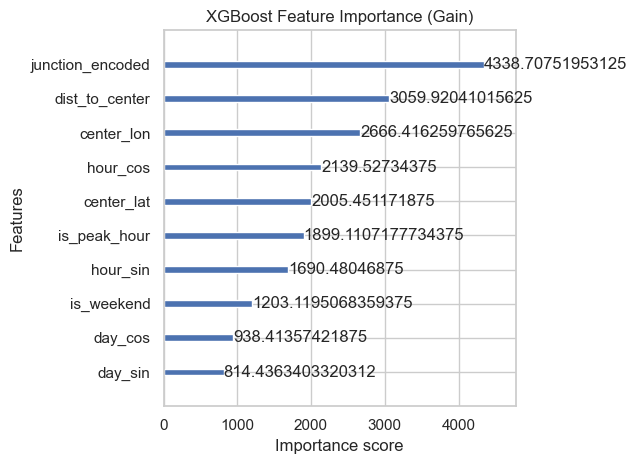

In [19]:
print("1. Preparing Base Spatio-Temporal Data...")
hourly_data = hotspot_records.groupby(['hex_id', 'day_of_week', 'hour']).agg(
    violation_volume=('id', 'count')
).reset_index()

hourly_data = pd.merge(
    hourly_data,
    final_hotspots[['hex_id', 'center_lat', 'center_lon', 'location_weight', 'primary_junction']],
    on='hex_id'
)

hourly_data['time_weight'] = hourly_data['hour'].apply(lambda h: 1.2 if h in [8, 9, 10, 11, 17, 18, 19, 20] else 1.0)
hourly_data['target_impact'] = hourly_data['violation_volume'] * hourly_data['time_weight'] * hourly_data['location_weight']

print("2. Engineering features (no junction_hour / junction_day -- those caused the crash)...")
hourly_data['primary_junction_str'] = hourly_data['primary_junction'].astype(str)
hourly_data['is_weekend'] = hourly_data['day_of_week'].isin(['Saturday', 'Sunday']).astype(int)
hourly_data['is_peak_hour'] = hourly_data['hour'].apply(lambda h: 1 if h in [8, 9, 10, 11, 17, 18, 19, 20] else 0)
hourly_data['hour_sin'] = np.sin(2 * np.pi * hourly_data['hour'] / 24.0)
hourly_data['hour_cos'] = np.cos(2 * np.pi * hourly_data['hour'] / 24.0)
day_map = {'Monday': 0, 'Tuesday': 1, 'Wednesday': 2, 'Thursday': 3, 'Friday': 4, 'Saturday': 5, 'Sunday': 6}
hourly_data['day_idx'] = hourly_data['day_of_week'].map(day_map)
hourly_data['day_sin'] = np.sin(2 * np.pi * hourly_data['day_idx'] / 7.0)
hourly_data['day_cos'] = np.cos(2 * np.pi * hourly_data['day_idx'] / 7.0)

def haversine(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    c = 2 * np.arcsin(np.sqrt(np.sin((lat2 - lat1) / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin((lon2 - lon1) / 2) ** 2))
    return 6371 * c

hourly_data['dist_to_center'] = haversine(hourly_data['center_lat'], hourly_data['center_lon'], 12.9716, 77.5946)

print("3. Encoding (with a reserved Unknown class so the API never crashes on a new junction) and splitting...")
known_junctions = list(hourly_data['primary_junction_str'].unique()) + ['__UNKNOWN__']
le_junc = LabelEncoder()
le_junc.fit(known_junctions)
hourly_data['junction_encoded'] = le_junc.transform(hourly_data['primary_junction_str'])

features = [
    'center_lat', 'center_lon', 'is_weekend', 'is_peak_hour',
    'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'dist_to_center',
    'junction_encoded'
]

X_train, X_test, y_train, y_test = train_test_split(
    hourly_data[features], hourly_data['target_impact'], test_size=0.2, random_state=42
)

print("4. Training XGBoost...")
xgb_model = xgb.XGBRegressor(
    n_estimators=400, max_depth=8, learning_rate=0.03,
    subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1
)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

print(f"\n--- Final Model Evaluation (leakage-free, crash-free) ---")
print(f"Model Mean Squared Error: {mean_squared_error(y_test, xgb_preds):.2f}")
print(f"XGBoost R^2 Score: {r2_score(y_test, xgb_preds):.4f}")

plt.figure(figsize=(9, 5))
xgb.plot_importance(xgb_model, max_num_features=10, importance_type='gain', title='XGBoost Feature Importance (Gain)')
plt.tight_layout()
plt.show()

# import joblib
# import os

# print("\n5. Exporting artifacts for FastAPI...")
# os.makedirs("src/model/artifacts/", exist_ok=True)

# joblib.dump(xgb_model, "src/model/artifacts/xgb_master.pkl")
# joblib.dump(le_junc, "src/model/artifacts/junction_encoder.pkl")
# joblib.dump({
#     "feature_order": features,
#     "unknown_junction_label": "__UNKNOWN__",
#     "max_target_impact": float(hourly_data['target_impact'].max()),
# }, "src/model/artifacts/meta.pkl")
# # This is the piece your original export was missing: the API needs the
# # hotspot table itself (not just the model) to serve /hotspots and to look
# # up coordinates/junction for a given hex_id at prediction time.
# final_hotspots.to_json("src/model/artifacts/final_hotspots.json", orient="records")

# print("Export complete -> src/model/artifacts/xgb_master.pkl, junction_encoder.pkl, meta.pkl, final_hotspots.json")